In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Tesis/goodbooks_10k.csv")

df.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


### Carga y limpieza de datos de Tags

In [21]:
# Cargar book_tags.csv
book_tags_df = pd.read_csv('/content/drive/MyDrive/Tesis/book_tags.csv')

# Cargar tags.csv
tags_df = pd.read_csv('/content/drive/MyDrive/Tesis/tags.csv')

print("book_tags_df.head():")
display(book_tags_df.head())
print("\ntags_df.head():")
display(tags_df.head())

book_tags_df.head():


,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716



tags_df.head():


,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-


### Limpieza y procesamiento de tags

Voy a filtrar los tags que parecen irrelevantes (por ejemplo, números, strings muy cortos o con muchos caracteres especiales) y luego fusionarlos para obtener una lista de tags por libro.

In [22]:
import re

# Función para limpiar tags
def clean_tag(tag):
    # Eliminar tags que son solo números o tienen una estructura similar a '--122-'
    if re.fullmatch(r'--?\d+-*', tag) or re.fullmatch(r'\d+', tag):
        return None
    # Eliminar tags que son muy cortos y no significativos
    if len(tag) <= 2:
        return None
    # Eliminar tags que son solo caracteres especiales o no alfanuméricos
    if not re.search(r'[a-zA-Z0-9]', tag):
        return None
    # Convertir a minúsculas y limpiar espacios en blanco
    return tag.lower().strip()

# Aplicar la limpieza de tags
tags_df['cleaned_tag'] = tags_df['tag_name'].apply(clean_tag)

# Filtrar tags nulos después de la limpieza
cleaned_tags_df = tags_df.dropna(subset=['cleaned_tag'])

print("Tags después de la limpieza (primeros 15):")
display(cleaned_tags_df.head(15))

# Fusionar book_tags_df con cleaned_tags_df para obtener los nombres de los tags limpios
merged_tags_df = pd.merge(book_tags_df, cleaned_tags_df, on='tag_id', how='inner')

# Eliminar la columna 'count' como se indicó y 'tag_name' original
merged_tags_df = merged_tags_df.drop(columns=['count', 'tag_name'])

# Renombrar 'goodreads_book_id' a 'book_id' para la fusión con el DataFrame principal
merged_tags_df = merged_tags_df.rename(columns={'goodreads_book_id': 'book_id'})

print("\nmerged_tags_df.head():")
display(merged_tags_df.head())

# Agrupar por book_id y recolectar todos los tags limpios en una lista
book_id_to_tags = merged_tags_df.groupby('book_id')['cleaned_tag'].apply(list).reset_index(name='book_tags')

print("\nbook_id_to_tags.head():")
display(book_id_to_tags.head())


Tags después de la limpieza (primeros 15):


,tag_id,tag_name,cleaned_tag
19,19,--available-at-raspberrys--,--available-at-raspberrys--
21,21,-calif--,-calif--
22,22,-d-c--,-d-c--
23,23,-dean,-dean
24,24,-england-,-england-
25,25,-fiction,-fiction
26,26,-fictional,-fictional
27,27,-fictitious,-fictitious
28,28,-football-,-football-
29,29,-george,-george



merged_tags_df.head():


,book_id,tag_id,cleaned_tag
0,1,30574,to-read
1,1,11305,fantasy
2,1,11557,favorites
3,1,8717,currently-reading
4,1,33114,young-adult



book_id_to_tags.head():


,book_id,book_tags
0,1,"[to-read, fantasy, favorites, currently-readin..."
1,2,"[to-read, currently-reading, fantasy, favorite..."
2,3,"[to-read, favorites, fantasy, currently-readin..."
3,5,"[favorites, fantasy, currently-reading, young-..."
4,6,"[fantasy, young-adult, fiction, harry-potter, ..."


In [ ]:
from IPython.display import Image

# Get a random index
random_index = np.random.randint(0, len(df))

# Get the image_url for the random index
random_image_url = df.loc[random_index, 'image_url']

# Display the image
print(f"Random Book Cover URL: {random_image_url}")
display(Image(url=random_image_url))

Random Book Cover URL: https://images.gr-assets.com/books/1457914582m/28220985.jpg


### Identificando libros sin imagen de portada (URL 'nophoto')

In [ ]:
nophoto_url = 'https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png'

books_without_cover = df[df['image_url'] == nophoto_url]

print(f"Se encontraron {len(books_without_cover)} libros sin imagen de portada válida.")
display(books_without_cover.head())

Se encontraron 3332 libros sin imagen de portada válida.


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
32,33,930,929,1558965,220,739326228,9.780739e+12,Arthur Golden,1997.0,Memoirs of a Geisha,...,1300209,1418172,25605,23500,59033,258700,517157,559782,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
41,42,1934,1934,3244642,1707,451529308,9.780452e+12,Louisa May Alcott,1868.0,Little Women,...,1257121,1314293,17090,31645,70011,250794,426280,535563,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
62,63,6185,6185,1565818,2498,393978893,9.780394e+12,"Emily Brontë, Richard J. Dunn",1847.0,Wuthering Heights,...,899195,1001135,26157,46469,84084,215320,309180,346082,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
77,78,5139,5139,38765,129,307275558,9.780307e+12,Lauren Weisberger,2003.0,The Devil Wears Prada,...,665930,679845,8024,24231,58323,192366,226675,178250,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
83,84,7677,6424171,3376836,176,030734813X,9.780307e+12,Michael Crichton,1990.0,Jurassic Park,...,447833,650483,8143,15736,34222,138327,231583,230615,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...


In [33]:
df[df["original_title"] == "To Kill a Mockingbird	"]

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url


### Recuperando portadas de libros usando la API de Google Books y el ISBN13

Podemos usar la API de Google Books para buscar información de libros, incluyendo sus portadas, utilizando el ISBN13. El endpoint para buscar por ISBN es `https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn13}`.

In [ ]:
import requests
from IPython.display import Image
from google.colab import userdata
import pandas as pd
import tenacity # Importar la librería tenacity
import logging # Importar la librería de logging
from tenacity import before_sleep_log # Importar before_sleep_log explícitamente

# Define a custom exception for rate limit
class RateLimitExceededError(Exception):
    pass

# Configurar el logger
logging.basicConfig(level=logging.INFO) # Puedes ajustar el nivel de logging (INFO, DEBUG, WARNING, ERROR)
logger = logging.getLogger(__name__)

def get_book_details_from_isbn13(isbn13):
    """
    Recupera la URL de la portada de un libro usando el ISBN13 desde la API de Google Books.
    Los géneros ya no se recuperan de esta API y se devuelven como una lista vacía.
    """
    if pd.isna(isbn13):
        return None, [] # Return empty list for genres

    # Asegurarse de que el ISBN13 sea una cadena y tenga el formato correcto
    # Convertir a int y luego a str para manejar la representación de float de los ISBNs
    try:
        isbn13_str = str(int(isbn13))
    except ValueError: # Maneja casos donde isbn13 podría ser 'nan' o no numérico
        return None, [] # Return empty list for genres

    # Configurar el reintento con retroceso exponencial
    @tenacity.retry(
        wait=tenacity.wait_exponential(multiplier=1, min=4, max=10),
        stop=tenacity.stop_after_attempt(3),
        retry=tenacity.retry_if_exception_type(requests.exceptions.RequestException),
        before_sleep=before_sleep_log(logger, logging.DEBUG) # Usar before_sleep_log con el logger
    )
    def _fetch_book_data_with_retry(isbn13_str_inner):
        url = f"https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn13_str_inner}&key={userdata.get('GOOGLE_BOOKS_API_KEY')}"
        response = requests.get(url)
        response.raise_for_status()  # Lanza una excepción si la respuesta contiene un error de estado HTTP
        return response.json()

    try:
        data = _fetch_book_data_with_retry(isbn13_str)

        image_url = None

        if data['totalItems'] > 0:
            volume_info = data['items'][0]['volumeInfo']

            # Intentar obtener el thumbnail
            image_links = volume_info.get('imageLinks', {})
            size = 'thumbnail'
            if size in image_links:
              image_url = image_links[size]

        return image_url, [] # Always return empty list for genres
    except requests.exceptions.RequestException as e:
        # This block catches direct RequestExceptions (like HTTPError) if they occur
        # before tenacity's retry mechanism exhausts, or if retry is not used.
        status_code_info = ""
        if hasattr(e, 'response') and e.response is not None:
            status_code_info = f" (Status Code: {e.response.status_code})"
        print(f"Error de solicitud HTTP para ISBN13 {isbn13_str}: {e}{status_code_info}")
        if hasattr(e, 'response') and e.response is not None and e.response.status_code == 429:
            raise RateLimitExceededError(f"Rate limit exceeded for ISBN13 {isbn13_str}") from e
        return None, [] # Return empty list for genres
    except tenacity.RetryError as retry_e:
        # This block catches the RetryError raised by tenacity when all attempts fail.
        # The actual exception that caused the last failure is stored in retry_e.last_attempt.exception()
        original_exception = retry_e.last_attempt.exception()
        status_code_info = ""
        if isinstance(original_exception, requests.exceptions.HTTPError) and hasattr(original_exception, 'response') and original_exception.response is not None:
            status_code_info = f" (Status Code: {original_exception.response.status_code})"
        print(f"Error de reintento al consultar la API de Google Books para ISBN13 {isbn13_str}: {original_exception.__class__.__name__} - {original_exception}{status_code_info}")
        if isinstance(original_exception, requests.exceptions.HTTPError) and original_exception.response.status_code == 429:
            raise RateLimitExceededError(f"Rate limit exceeded after retries for ISBN13 {isbn13_str}") from original_exception
        return None, [] # Return empty list for genres
    except Exception as e:
        print(f"Error inesperado al procesar ISBN13 {isbn13_str}: {e}")
        return None, [] # Return empty list for genres

# Obtener un ISBN13 de ejemplo del DataFrame
sample_isbn13 = df['isbn13'].dropna().iloc[0]

# Si el ISBN13 es un float (como 9.780439e+12), lo convertimos a entero primero
if isinstance(sample_isbn13, float):
    sample_isbn13 = int(sample_isbn13)

print(f"Usando el ISBN13 de ejemplo: {sample_isbn13}")

# Recuperar la URL de la portada y los géneros (que ahora serán una lista vacía)
try:
    cover_url, book_genres = get_book_details_from_isbn13(sample_isbn13)

    if cover_url:
        print(f"Portada encontrada: {cover_url}")
        display(Image(url=cover_url))
    else:
        print("No se pudo encontrar la portada para el ISBN13 proporcionado.")

    if not book_genres: # Check if it's an empty list as expected
        print("Géneros ya no se recuperan de la API. La lista está vacía según lo esperado.")
    else:
        print(f"Géneros encontrados (inesperadamente): {book_genres}")
except RateLimitExceededError:
    print("El límite de tasa de la API de Google Books ha sido excedido durante la prueba.")

Usando el ISBN13 de ejemplo: 9780439023480
Portada encontrada: http://books.google.com/books/content?id=sJdUAzLUNyAC&printsec=frontcover&img=1&zoom=1&source=gbs_api


Géneros encontrados: ['Juvenile Fiction']


In [ ]:
import requests
from IPython.display import Image
from google.colab import userdata
import pandas as pd
import tenacity # Importar la librería tenacity
import logging # Importar la librería de logging
from tenacity import before_sleep_log # Importar before_sleep_log explícitamente

# Define a custom exception for rate limit
class RateLimitExceededError(Exception):
    pass

# Configurar el logger
logging.basicConfig(level=logging.INFO) # Puedes ajustar el nivel de logging (INFO, DEBUG, WARNING, ERROR)
logger = logging.getLogger(__name__)

def get_book_details_from_isbn13(isbn13):
    """
    Recupera la URL de la portada de un libro usando el ISBN13 desde la API de Google Books.
    Los géneros ya no se recuperan de esta API y se devuelven como una lista vacía.
    """
    if pd.isna(isbn13):
        return None, [] # Return empty list for genres

    # Asegurarse de que el ISBN13 sea una cadena y tenga el formato correcto
    # Convertir a int y luego a str para manejar la representación de float de los ISBNs
    try:
        isbn13_str = str(int(isbn13))
    except ValueError: # Maneja casos donde isbn13 podría ser 'nan' o no numérico
        return None, [] # Return empty list for genres

    # Configurar el reintento con retroceso exponencial
    @tenacity.retry(
        wait=tenacity.wait_exponential(multiplier=1, min=4, max=10),
        stop=tenacity.stop_after_attempt(3),
        retry=tenacity.retry_if_exception_type(requests.exceptions.RequestException),
        before_sleep=before_sleep_log(logger, logging.DEBUG) # Usar before_sleep_log con el logger
    )
    def _fetch_book_data_with_retry(isbn13_str_inner):
        url = f"https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn13_str_inner}&key={userdata.get('GOOGLE_BOOKS_API_KEY')}"
        response = requests.get(url)
        response.raise_for_status()  # Lanza una excepción si la respuesta contiene un error de estado HTTP
        return response.json()

    try:
        data = _fetch_book_data_with_retry(isbn13_str)

        image_url = None

        if data['totalItems'] > 0:
            volume_info = data['items'][0]['volumeInfo']

            # Intentar obtener el thumbnail
            image_links = volume_info.get('imageLinks', {})
            size = 'thumbnail'
            if size in image_links:
              image_url = image_links[size]

        return image_url, [] # Always return empty list for genres
    except requests.exceptions.RequestException as e:
        # This block catches direct RequestExceptions (like HTTPError) if they occur
        # before tenacity's retry mechanism exhausts, or if retry is not used.
        status_code_info = ""
        if hasattr(e, 'response') and e.response is not None:
            status_code_info = f" (Status Code: {e.response.status_code})"
        print(f"Error de solicitud HTTP para ISBN13 {isbn13_str}: {e}{status_code_info}")
        if hasattr(e, 'response') and e.response is not None and e.response.status_code == 429:
            raise RateLimitExceededError(f"Rate limit exceeded for ISBN13 {isbn13_str}") from e
        return None, [] # Return empty list for genres
    except tenacity.RetryError as retry_e:
        # This block catches the RetryError raised by tenacity when all attempts fail.
        # The actual exception that caused the last failure is stored in retry_e.last_attempt.exception()
        original_exception = retry_e.last_attempt.exception()
        status_code_info = ""
        if isinstance(original_exception, requests.exceptions.HTTPError) and hasattr(original_exception, 'response') and original_exception.response is not None:
            status_code_info = f" (Status Code: {original_exception.response.status_code})"
        print(f"Error de reintento al consultar la API de Google Books para ISBN13 {isbn13_str}: {original_exception.__class__.__name__} - {original_exception}{status_code_info}")
        if isinstance(original_exception, requests.exceptions.HTTPError) and original_exception.response.status_code == 429:
            raise RateLimitExceededError(f"Rate limit exceeded after retries for ISBN13 {isbn13_str}") from original_exception
        return None, [] # Return empty list for genres
    except Exception as e:
        print(f"Error inesperado al procesar ISBN13 {isbn13_str}: {e}")
        return None, [] # Return empty list for genres

# Obtener un ISBN13 de ejemplo del DataFrame
sample_isbn13 = df['isbn13'].dropna().iloc[0]

# Si el ISBN13 es un float (como 9.780439e+12), lo convertimos a entero primero
if isinstance(sample_isbn13, float):
    sample_isbn13 = int(sample_isbn13)

print(f"Usando el ISBN13 de ejemplo: {sample_isbn13}")

# Recuperar la URL de la portada y los géneros (que ahora serán una lista vacía)
try:
    cover_url, book_genres = get_book_details_from_isbn13(sample_isbn13)

    if cover_url:
        print(f"Portada encontrada: {cover_url}")
        display(Image(url=cover_url))
    else:
        print("No se pudo encontrar la portada para el ISBN13 proporcionado.")

    if not book_genres: # Check if it's an empty list as expected
        print("Géneros ya no se recuperan de la API. La lista está vacía según lo esperado.")
    else:
        print(f"Géneros encontrados (inesperadamente): {book_genres}")
except RateLimitExceededError:
    print("El límite de tasa de la API de Google Books ha sido excedido durante la prueba.")

### Enriqueciendo el DataFrame principal (`df`) con portadas y géneros

Procederemos a iterar sobre los libros identificados sin portada (aquellos en `books_without_cover`) para intentar obtener sus URL de portada y géneros desde la API de Google Books. Implementaremos un retraso entre las llamadas a la API para evitar exceder los límites de la misma. Los resultados se guardarán incrementalmente en un archivo CSV para evitar la pérdida de datos.

In [ ]:
import time
import os

# Ruta para el archivo de resultados incrementales
enriched_output_path = '/content/enriched_books_data.csv'
drive_output_path = '/content/drive/MyDrive/Tesis/enriched_books_data.csv'

# Columnas para el DataFrame enriquecido
enriched_data = []

# Límite de llamadas a la API por sesión (para respetar el límite diario de 1000)
max_api_calls_per_session = 950 # Dejar un pequeño margen
api_calls_made_this_session = 0

# Cargar datos existentes si el archivo ya existe
# Priorizar el archivo en Google Drive si existe
if os.path.exists(drive_output_path):
    existing_enriched_df = pd.read_csv(drive_output_path)
    enriched_data = existing_enriched_df.to_dict('records')
    print(f"Cargados {len(enriched_data)} registros existentes de Google Drive: {drive_output_path}.")
elif os.path.exists(enriched_output_path):
    existing_enriched_df = pd.read_csv(enriched_output_path)
    enriched_data = existing_enriched_df.to_dict('records')
    print(f"Cargados {len(enriched_data)} registros existentes de {enriched_output_path}.")

# Crear un set de ISBN13 ya procesados para evitar duplicados
processed_isbns = {record['isbn13'] for record in enriched_data if 'isbn13' in record and pd.notna(record['isbn13'])}

# Filtrar df para procesar solo los ISBN13 que no han sido procesados
# Ahora procesaremos todos los libros del df original
books_to_process = df[~df['isbn13'].isin(processed_isbns)].copy()

print(f"Se procesarán {len(books_to_process)} libros nuevos (o no procesados) para enriquecer.")

# Iterar sobre los libros para obtener la información de la API
for index, row in books_to_process.iterrows():
    if api_calls_made_this_session >= max_api_calls_per_session:
        print(f"Límite de API calls ({max_api_calls_per_session}) alcanzado para esta sesión. Guardando progreso.")
        break

    book_id = row['book_id']
    isbn13 = row['isbn13']

    if pd.isna(isbn13):
        print(f"Saltando libro con book_id {book_id}: ISBN13 es nulo.")
        continue

    try:
        cover_url, genres = get_book_details_from_isbn13(isbn13)
        api_calls_made_this_session += 1
    except RateLimitExceededError as e:
        print(f"Error: {e}. Deteniendo el procesamiento y guardando el progreso.")
        # Save the current progress before breaking
        temp_df = pd.DataFrame(enriched_data)
        temp_df.to_csv(enriched_output_path, index=False)
        temp_df.to_csv(drive_output_path, index=False) # Guardar también en Google Drive
        print(f"Guardados {len(enriched_data)} registros en {enriched_output_path} y {drive_output_path} antes de detener.")
        break # Break the loop immediately on rate limit error

    # Usar la URL recuperada de la API. Si la API no retorna nada, será None.
    final_image_url = cover_url

    enriched_data.append({
        'book_id': book_id,
        'isbn13': isbn13,
        'retrieved_image_url': final_image_url,
        'retrieved_genres': genres
    })

    # Guardar incrementalmente cada 100 libros o al final de la iteración
    # También guardar si se alcanzó el límite de API calls
    if (len(enriched_data) % 100 == 0) or (index == books_to_process.index[-1]) or (api_calls_made_this_session >= max_api_calls_per_session):
        temp_df = pd.DataFrame(enriched_data)
        temp_df.to_csv(enriched_output_path, index=False)
        temp_df.to_csv(drive_output_path, index=False) # Guardar también en Google Drive
        print(f"Guardados {len(enriched_data)} registros en {enriched_output_path} y {drive_output_path}")

    # Esperar para evitar exceder los límites de la API
    time.sleep(0.1)

print("Proceso de enriquecimiento completado o límite de API alcanzado/detenido por error 429.")

# Cargar el DataFrame enriquecido final
enriched_df = pd.DataFrame(enriched_data)
display(enriched_df.head())
print(f"Shape of enriched_df: {enriched_df.shape}")

Cargados 7250 registros existentes de Google Drive: /content/drive/MyDrive/Tesis/enriched_books_data.csv.
Se procesarán 2560 libros nuevos (o no procesados) para enriquecer.
Saltando libro con book_id 9418327: ISBN13 es nulo.
Saltando libro con book_id 7604: ISBN13 es nulo.
Saltando libro con book_id 49552: ISBN13 es nulo.
Saltando libro con book_id 10664113: ISBN13 es nulo.
Saltando libro con book_id 11505797: ISBN13 es nulo.
Saltando libro con book_id 16068905: ISBN13 es nulo.
Saltando libro con book_id 16143347: ISBN13 es nulo.
Saltando libro con book_id 7190: ISBN13 es nulo.
Saltando libro con book_id 1923820: ISBN13 es nulo.
Saltando libro con book_id 25041504: ISBN13 es nulo.
Saltando libro con book_id 13372690: ISBN13 es nulo.
Saltando libro con book_id 10975: ISBN13 es nulo.
Saltando libro con book_id 13453029: ISBN13 es nulo.
Saltando libro con book_id 15760001: ISBN13 es nulo.
Saltando libro con book_id 16070903: ISBN13 es nulo.
Saltando libro con book_id 15749186: ISBN13 es 

,book_id,isbn13,retrieved_image_url,retrieved_genres
0,2767052,9.780439e+12,http://books.google.com/books/content?id=sJdUA...,['Juvenile Fiction']
1,3,9.780440e+12,NaN,NaN
2,41865,9.780316e+12,NaN,['Young Adult Fiction']
3,2657,9.780061e+12,http://books.google.com/books/content?id=ncuX8...,['Fiction']
4,4671,9.780743e+12,http://books.google.com/books/content?id=fIlQD...,['Fiction']


Shape of enriched_df: (8200, 4)


### Consolidando los datos en `final_books_df`

Ahora, fusionaremos los datos enriquecidos con el DataFrame original (`df`). Luego, crearemos el `final_books_df` seleccionando solo las columnas requeridas por el usuario: `id`, `original_title`, `authors`, `genres` y `image_url`.

In [35]:
# Fusionar los datos enriquecidos con el DataFrame original
# Primero, asegurarnos de que la columna de géneros sea una lista en el df original también para la fusión

# Reemplazar la URL 'nophoto' en el df original con las URL recuperadas
df_temp = df.copy()

# Asegurarse de que 'retrieved_genres' sea una cadena para poder usar ast.literal_eval más adelante si es necesario
# o manejar como listas directamente si la carga de CSV no lo convierte a string
if 'retrieved_genres' in enriched_df.columns:
    # Aseguramos que los géneros sean tratados como listas si vienen como strings (ej. desde un CSV)
    enriched_df['retrieved_genres'] = enriched_df['retrieved_genres'].apply(lambda x: eval(x) if isinstance(x, str) else x)

# Fusionar df_temp con enriched_df para obtener las nuevas URLs y géneros
merged_df = pd.merge(df_temp, enriched_df[['book_id', 'retrieved_image_url', 'retrieved_genres']], on='book_id', how='left')

# Actualizar 'image_url': siempre usar la URL recuperada de la API, o None si no se encontró.
merged_df['image_url'] = merged_df['retrieved_image_url']

# Actualizar 'genres': siempre usar los géneros recuperados de la API. Si es None o vacío, usar una lista vacía.
merged_df['genres'] = merged_df['retrieved_genres'].apply(lambda x: x if (isinstance(x, list) and x) else [])

# Seleccionar las columnas finales y renombrar 'original_title' a 'titulo'
final_books_df = merged_df[[
    'id',
    'book_id',
    'original_title',
    'authors',
    'genres',
    'image_url'
]].rename(columns={'original_title': 'titulo'})


# Display the head and shape of the final DataFrame
print("\nFinal Books DataFrame Head:")
display(final_books_df.head())
print(f"\nShape of final_books_df: {final_books_df.shape}")


Final Books DataFrame Head:


,id,book_id,titulo,authors,genres,image_url
0,1,2767052,The Hunger Games,Suzanne Collins,[Juvenile Fiction],http://books.google.com/books/content?id=sJdUA...
1,2,3,Harry Potter and the Philosopher's Stone,"J.K. Rowling, Mary GrandPré",[],NaN
2,3,41865,Twilight,Stephenie Meyer,[Young Adult Fiction],NaN
3,4,2657,To Kill a Mockingbird,Harper Lee,[Fiction],http://books.google.com/books/content?id=ncuX8...
4,5,4671,The Great Gatsby,F. Scott Fitzgerald,[Fiction],http://books.google.com/books/content?id=fIlQD...



Shape of final_books_df: (10000, 6)


### Distribución de Géneros en `final_books_df`

Para entender la diversidad de los libros en nuestro dataset, vamos a visualizar la distribución de los géneros o etiquetas. Primero, necesitamos aplanar la lista de géneros para poder contar la frecuencia de cada uno.


Top 15 Géneros más comunes:


,count
Fiction,3062
Juvenile Fiction,968
Biography & Autobiography,347
Comics & Graphic Novels,187
Young Adult Fiction,186
History,116
Business & Economics,103
Juvenile Nonfiction,81
Religion,70
Drama,69


/tmp/ipykernel_6182/3084426619.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.head(15).index, y=genre_counts.head(15).values, palette='viridis')


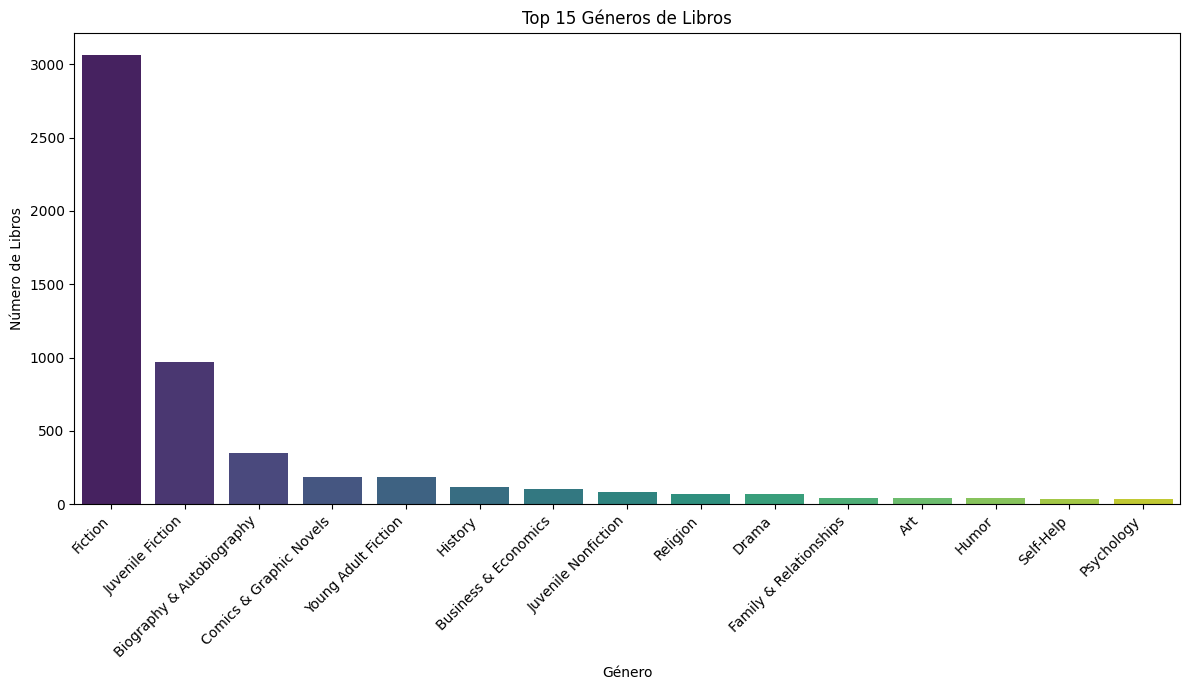

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aplanar la lista de géneros
all_genres = [genre for sublist in final_books_df['genres'] if isinstance(sublist, list) for genre in sublist]

# Contar la frecuencia de cada género
genre_counts = pd.Series(all_genres).value_counts()

# Mostrar los 15 géneros más comunes
print("\nTop 15 Géneros más comunes:")
display(genre_counts.head(15))

# Visualizar la distribución de géneros
plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts.head(15).index, y=genre_counts.head(15).values, palette='viridis')
plt.title('Top 15 Géneros de Libros')
plt.xlabel('Género')
plt.ylabel('Número de Libros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cantidad de libros con URL de imagen: 6585

Top 15 Géneros más comunes (libros con URL de imagen):


,count
Fiction,3006
Juvenile Fiction,922
Biography & Autobiography,343
Young Adult Fiction,178
Comics & Graphic Novels,167
History,112
Business & Economics,100
Juvenile Nonfiction,72
Religion,67
Drama,67


/tmp/ipykernel_6182/639776032.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts_filtered.head(15).index, y=genre_counts_filtered.head(15).values, palette='viridis')


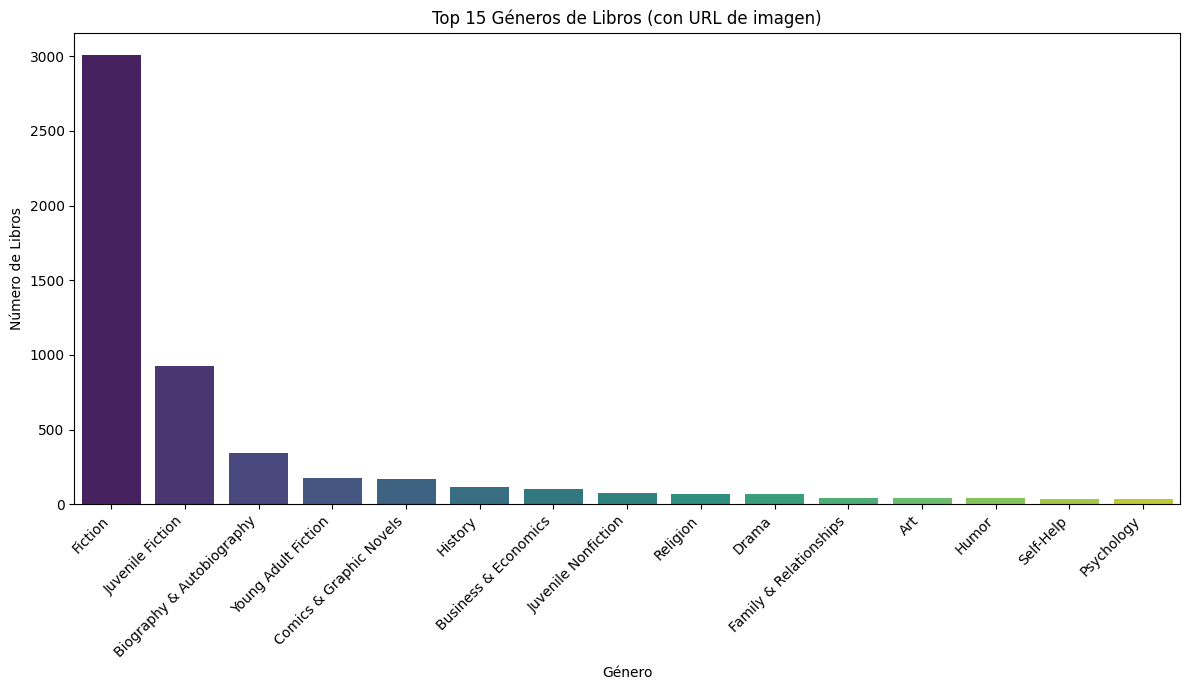

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar libros que tienen una URL de imagen válida
books_with_image_url = final_books_df[final_books_df['image_url'].notna() & (final_books_df['image_url'] != '')].copy()

print(f"Cantidad de libros con URL de imagen: {len(books_with_image_url)}")

# Aplanar la lista de géneros para los libros filtrados
all_genres_filtered = [genre for sublist in books_with_image_url['genres'] if isinstance(sublist, list) for genre in sublist]

# Contar la frecuencia de cada género en el conjunto filtrado
genre_counts_filtered = pd.Series(all_genres_filtered).value_counts()

# Mostrar los 15 géneros más comunes del conjunto filtrado
print("\nTop 15 Géneros más comunes (libros con URL de imagen):")
display(genre_counts_filtered.head(15))

# Visualizar la distribución de géneros para el conjunto filtrado
plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts_filtered.head(15).index, y=genre_counts_filtered.head(15).values, palette='viridis')
plt.title('Top 15 Géneros de Libros (con URL de imagen)')
plt.xlabel('Género')
plt.ylabel('Número de Libros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [41]:
books_with_image_url

,id,book_id,titulo,authors,genres,image_url,book_tags
0,1,2767052,The Hunger Games,Suzanne Collins,[Juvenile Fiction],http://books.google.com/books/content?id=sJdUA...,"[favorites, currently-reading, young-adult, fi..."
1,4,2657,To Kill a Mockingbird,Harper Lee,[Fiction],http://books.google.com/books/content?id=ncuX8...,"[classics, favorites, to-read, classic, histor..."
2,5,4671,The Great Gatsby,F. Scott Fitzgerald,[Fiction],http://books.google.com/books/content?id=fIlQD...,"[classics, favorites, fiction, classic, books-..."
3,6,11870085,The Fault in Our Stars,John Green,[Young Adult Fiction],http://books.google.com/books/content?id=Dc2LD...,"[favorites, to-read, young-adult, fiction, rom..."
4,7,5907,The Hobbit or There and Back Again,J.R.R. Tolkien,[Juvenile Fiction],http://books.google.com/books/content?id=ljWL5...,"[fantasy, favorites, classics, to-read, fictio..."
...,...,...,...,...,...,...,...
6580,8845,6713071,NaN,"George Carlin, Tony Hendra",[Fiction],http://books.google.com/books/content?id=P1v64...,"[to-read, currently-reading, biography, non-fi..."
6581,8846,8701960,"The Information: A History, a Theory, a Flood",James Gleick,[Business & Economics],http://books.google.com/books/content?id=ZOYJA...,"[to-read, currently-reading, non-fiction, scie..."
6582,8847,96642,Rocket Boys,Homer Hickam,[Biography & Autobiography],http://books.google.com/books/content?id=cl8ie...,"[to-read, currently-reading, science, non-fict..."
6583,8848,278102,NaN,Danielle Steel,[Fiction],http://books.google.com/books/content?id=-v1qk...,"[romance, danielle-steel, currently-reading, f..."


### Fusionando `books_with_image_url` con los tags procesados

Ahora, fusionaremos el DataFrame de libros con URL de imagen (`books_with_image_url`) con los tags que hemos agrupado por `book_id` (`book_id_to_tags`). La columna resultante `book_tags` de la fusión se renombrará a `genres`.

In [44]:
# Realizar la fusión entre books_with_image_url y book_id_to_tags
# Usamos 'id' de books_with_image_url y 'book_id' de book_id_to_tags para la fusión
books_with_image_url = pd.merge(
    books_with_image_url,
    book_id_to_tags,
    left_on='book_id',
    right_on='book_id',
    how='left'
)

# Eliminar la columna 'book_id' redundante de la fusión
books_with_image_url = books_with_image_url.drop(columns=['genres'])

# Renombrar 'book_tags' a 'genres' para que se ajuste al esquema final
books_with_image_url = books_with_image_url.rename(columns={'book_tags': 'genres'})

# Rellenar los valores NaN en 'genres' con listas vacías si algún libro no tiene tags
books_with_image_url['genres'] = books_with_image_url['genres'].apply(lambda x: x if isinstance(x, list) else [])

print("DataFrame 'books_with_image_url' después de añadir los tags (genres):")
display(books_with_image_url.head())
print(f"Shape of books_with_image_url: {books_with_image_url.shape}")

DataFrame 'books_with_image_url' después de añadir los tags (genres):


,id,book_id,titulo,authors,image_url,genres
0,1,2767052,The Hunger Games,Suzanne Collins,http://books.google.com/books/content?id=sJdUA...,"[favorites, currently-reading, young-adult, fi..."
1,4,2657,To Kill a Mockingbird,Harper Lee,http://books.google.com/books/content?id=ncuX8...,"[classics, favorites, to-read, classic, histor..."
2,5,4671,The Great Gatsby,F. Scott Fitzgerald,http://books.google.com/books/content?id=fIlQD...,"[classics, favorites, fiction, classic, books-..."
3,6,11870085,The Fault in Our Stars,John Green,http://books.google.com/books/content?id=Dc2LD...,"[favorites, to-read, young-adult, fiction, rom..."
4,7,5907,The Hobbit or There and Back Again,J.R.R. Tolkien,http://books.google.com/books/content?id=ljWL5...,"[fantasy, favorites, classics, to-read, fictio..."


Shape of books_with_image_url: (6585, 6)


In [45]:
output_path_for_embeddings = '/content/drive/MyDrive/Tesis/books_for_sentence_bert.csv'

# Guardar el DataFrame books_with_image_url en un archivo CSV
books_with_image_url.to_csv(output_path_for_embeddings, index=False)

print(f"DataFrame 'books_with_image_url' guardado exitosamente en: {output_path_for_embeddings}")

DataFrame 'books_with_image_url' guardado exitosamente en: /content/drive/MyDrive/Tesis/books_for_sentence_bert.csv


Cantidad de libros con URL de imagen: 6585

Top 15 Géneros más comunes (libros con URL de imagen):


,count
to-read,6575
favorites,6512
owned,6500
books-i-own,6481
currently-reading,6423
library,6371
owned-books,6168
fiction,5991
to-buy,5867
default,5624


/tmp/ipykernel_6182/1008825614.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts_filtered.head(15).index, y=genre_counts_filtered.head(15).values, palette='viridis')


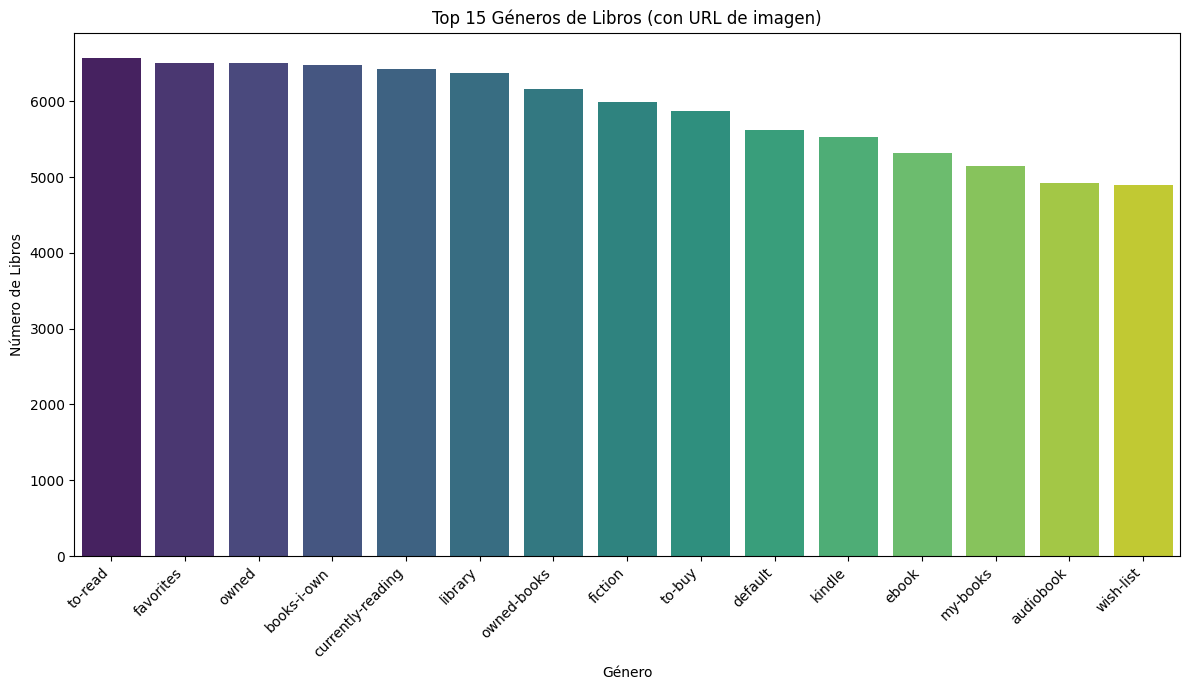

In [46]:
print(f"Cantidad de libros con URL de imagen: {len(books_with_image_url)}")

# Aplanar la lista de géneros para los libros filtrados
all_genres_filtered = [genre for sublist in books_with_image_url['genres'] if isinstance(sublist, list) for genre in sublist]

# Contar la frecuencia de cada género en el conjunto filtrado
genre_counts_filtered = pd.Series(all_genres_filtered).value_counts()

# Mostrar los 15 géneros más comunes del conjunto filtrado
print("\nTop 15 Géneros más comunes (libros con URL de imagen):")
display(genre_counts_filtered.head(15))

# Visualizar la distribución de géneros para el conjunto filtrado
plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts_filtered.head(15).index, y=genre_counts_filtered.head(15).values, palette='viridis')
plt.title('Top 15 Géneros de Libros (con URL de imagen)')
plt.xlabel('Género')
plt.ylabel('Número de Libros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()